#  Social Media and Network Analysis – Assignment 2

## Import Libraries and Download NLTK Resources

Imports all required libraries for data processing, text cleaning, topic modelling, sentiment analysis, and visualisation, and downloads necessary NLTK datasets for tokenisation, stopwords, and sentiment analysis.

In [64]:
import pandas as pd
import numpy as np
import pyarrow.parquet as pq
import os
import re
import string
import nltk
import emoji
from nltk.tokenize import TweetTokenizer
from nltk.stem import WordNetLemmatizer
import matplotlib.pyplot as plt

# Topic 
from collections import Counter
import pyLDAvis
import pyLDAvis.lda_model
from wordcloud import WordCloud
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.decomposition import LatentDirichletAllocation

from nltk.sentiment.vader import SentimentIntensityAnalyzer
from nltk.corpus import stopwords


nltk.download('vader_lexicon')
nltk.download('wordnet')
nltk.download('stopwords')
nltk.download('punkt')

[nltk_data] Downloading package vader_lexicon to
[nltk_data]     /Users/daniadonai/nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     /Users/daniadonai/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/daniadonai/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to
[nltk_data]     /Users/daniadonai/nltk_data...
[nltk_data]   Package punkt is already up-to-date!


True

In [3]:
import os
print(os.getcwd())

/Users/daniadonai/Downloads


## Load and Merge Gaming Dataset with Community Information

Loads the 2020 gaming dataset and community detection results, then merges user-level community assignments to filter the data to only include users belonging to large communities (≥50 users).

In [4]:
# Load original 2020 gaming data
# Columns: post_id, publish_date, user_id, parent_id, parent_user_id, interaction_type, content
df = pd.read_parquet("data/filtered_gaming_2020.parquet")
print(f"Loaded {len(df):,} rows")

# Load community detection results
# large_community_users.csv: maps user_id → community_id (only communities with ≥50 users)
user_community = pd.read_csv("data/large_community_users.csv")
print(f"Loaded user-community mapping: {len(user_community):,} users")
print(f"User_Community: {user_community.head()}")

# large_community_ids.csv: reference list of community IDs with their sizes
community_ref = pd.read_csv("data/large_community_ids_and_size.csv")
print(f"Loaded community reference: {len(community_ref)} communities")
print(f"Community Ref: {community_ref.head()}")

# Inner join keeps only users from large communities (≥50 users)
df = df.merge(user_community, on='user_id', how='inner')
print(f"Large communities dataset: {len(df):,} rows")
print(df.head())

Loaded 3,374,802 rows
Loaded user-community mapping: 879,627 users
User_Community:                                 user_id  community_id
0  4f047b87-9fff-5804-99f2-d60282b36b61             0
1  e1f21169-bbec-5443-acdc-473be51ec0db             0
2  d1416087-0246-5ce4-bd49-44b2d1d68343             0
3  c221fd3b-e303-512a-af0c-11dd7b13baf1             0
4  9d049a8f-63c8-56ad-b131-a3f673bc4198             1
Loaded community reference: 47 communities
Community Ref:    community_id    size  rank
0             5  161525     1
1             2  156915     2
2             6  128177     3
3             7   81282     4
4            16   78265     5
Large communities dataset: 3,192,856 rows
                                post_id        publish_date  \
0  c015fb34-9564-5a4b-b8d5-3743455b95ca 2020-01-01 00:00:00   
1  cc8f1c89-2874-5dae-920d-4472a9b933f2 2020-01-01 00:00:06   
2  449f46b0-f758-5c1b-add9-0d7930d8a23e 2020-01-01 00:00:08   
3  3c9c3e09-7182-5cba-94b3-c55762a49b57 2020-01-01 00:00:10  

# Text Pre-processing

## Text Preprocessing Functions for Topic and Sentiment Analysis

Defines two preprocessing functions: one for topic modelling that tokenises, cleans, and lemmatises text into word lists, and another for sentiment analysis that removes noise such as URLs and mentions while preserving sentence structure.

In [5]:
def preprocessContentForTopicAnalysis(text):   
    if not text or not isinstance(text, str):
        return []
    
    # Punctuation list
    lPunct = list(string.punctuation) + ['...', '’', '‘', '”', '“', '—', '–', '…']
    
    # Stopwords
    stopwords = set(nltk.corpus.stopwords.words('english') + lPunct + ['via', 'like', 'get', 'go', 'know', 'think', 'lol', 'lmao', 'rofl', 'lmaoo', 'lmfao', 'haha', 'hehe', 'aww', 'aw', 'awwww', 'aww', 'aww','omg', 'wow', 'oh', 'ah', 'uh', 'nvm', 'meh', 'ugh', 'smh', 'wtf','feel', 'feeling', 'feels'])
    
    # convert all to lower case
    text = text.lower()
        
    # remove emojis
    text = emoji.replace_emoji(text, replace='')  

    # remove urls
    regexHttp = re.compile(r"^http")

    # remove mentions
    text = re.sub(r'@\w+', '', text)
        
    # remove # symbol from hashtags
    text = re.sub(r'#(\w+)', r'\1', text)
    
    # tokenise
    tokenizer = nltk.tokenize.TweetTokenizer()
    lTokens = tokenizer.tokenize(text)
           
    # strip whitespaces before and after
    lTokens = [token.strip() for token in lTokens]

    filtered_tokens = [tok for tok in lTokens if tok not in stopwords and not any(c.isdigit() for c in tok) and regexHttp.match(tok) is None]
    lemmatizer = WordNetLemmatizer()
    lemmatized_tokens = [lemmatizer.lemmatize(tok) for tok in filtered_tokens]

    return [tok for tok in lemmatized_tokens if tok not in stopwords]
    
def preprocessContentForSentimentAnalysis(text):
    if not text or not isinstance(text, str):
        return ""
    
    # remove urls
    text = re.sub(r'http\S+|www\S+|https\S+', '', text)

    # remove mentions
    text = re.sub(r'@\w+', '', text)
    
    # remove whitespaces
    text = ' '.join(text.split())
    
    return text.strip()

## Preprocess Content for Topic Analysis

Fills missing values in the `content` column and applies a preprocessing function to generate cleaned text suitable for topic modelling.

In [8]:
# Preprocess content for topic analysis
df['content'] = df['content'].fillna("")
df['clean_topic_content'] = df['content'].apply(preprocessContentForTopicAnalysis)

In [9]:
df[["content", "clean_topic_content"]].head(20)

,content,clean_topic_content
0,Congrats,[congrats]
1,I get more birthday wishes on January 1st than...,"[birthday, wish, january, actual, birthday]"
2,i was like aww that nice.... oh nvm fuck the e...,"[nice, fuck, eagle]"
3,I’m upvoting this out of principle because it ...,"[upvoting, principle, picture, retro, gaming, ..."
4,I feel like that was unintentionally encouraging,"[unintentionally, encouraging]"
5,Wholesome 💯,[wholesome]
6,Get *Vectored*,[vectored]
7,Baba is mad that you reposted,"[baba, mad, reposted]"
8,the pokeball behind you guys in the picture co...,"[pokeball, behind, guy, picture, contains, chi..."
9,[ASSASSINS CREED] Am I the only one here who d...,"[assassin, creed, one, game, scene, outside, a..."


## Preprocess Content for Sentiment Analysis

Applies the `preprocessContentForSentimentAnalysis()` function to each value in the `content` column and stores the cleaned text in a new column called `clean_sentiment_content`.

In [10]:
# Preprocess content for sentiment analysis
df['clean_sentiment_content'] = df['content'].apply(preprocessContentForSentimentAnalysis)

In [12]:
df[["content", "clean_sentiment_content"]].head(20)

,content,clean_sentiment_content
0,Congrats,Congrats
1,I get more birthday wishes on January 1st than...,I get more birthday wishes on January 1st than...
2,i was like aww that nice.... oh nvm fuck the e...,i was like aww that nice.... oh nvm fuck the e...
3,I’m upvoting this out of principle because it ...,I’m upvoting this out of principle because it ...
4,I feel like that was unintentionally encouraging,I feel like that was unintentionally encouraging
5,Wholesome 💯,Wholesome 💯
6,Get *Vectored*,Get *Vectored*
7,Baba is mad that you reposted,Baba is mad that you reposted
8,the pokeball behind you guys in the picture co...,the pokeball behind you guys in the picture co...
9,[ASSASSINS CREED] Am I the only one here who d...,[ASSASSINS CREED] Am I the only one here who d...


## Validate Preprocessed Topic and Sentiment Data

Checks the preprocessing results for topic and sentiment analysis by identifying empty values and reporting summary statistics for both cleaned topic content and cleaned sentiment content.

In [13]:
# Check for empty arrays (topic analysis)
empty_topic_mask = df['clean_topic_content'].apply(len) == 0
empty_topic_count = empty_topic_mask.sum()
print(f"\n📊 TOPIC ANALYSIS PREPROCESSING:")
print(f"   Total rows processed: {len(df):,}")
print(f"   Empty arrays ([]): {empty_topic_count:,} ({empty_topic_count/len(df)*100:.2f}%)")
print(f"   Non-empty arrays: {len(df) - empty_topic_count:,}")

# Check for empty strings (sentiment analysis)
empty_sentiment_mask = (df['clean_sentiment_content'].isna()) | (df['clean_sentiment_content'].str.strip() == "")
empty_sentiment_count = empty_sentiment_mask.sum()
print(f"\n📊 SENTIMENT ANALYSIS PREPROCESSING:")
print(f"   Total rows processed: {len(df):,}")
print(f"   Empty strings: {empty_sentiment_count:,} ({empty_sentiment_count/len(df)*100:.2f}%)")
print(f"   Non-empty strings: {len(df) - empty_sentiment_count:,}")


📊 TOPIC ANALYSIS PREPROCESSING:
   Total rows processed: 3,192,856
   Empty arrays ([]): 46,176 (1.45%)
   Non-empty arrays: 3,146,680

📊 SENTIMENT ANALYSIS PREPROCESSING:
   Total rows processed: 3,192,856
   Empty strings: 2,110 (0.07%)
   Non-empty strings: 3,190,746


## Filter Valid Data for Topic and Sentiment Analysis

Removes rows with empty preprocessed content and creates separate DataFrames containing only valid data for topic analysis and sentiment analysis.

In [14]:
# For topic analysis (remove empty arrays)
df_topic_ready = df[df['clean_topic_content'].apply(len) > 0].copy()
print(f"Topic analysis ready: {len(df_topic_ready):,} rows")

# For sentiment analysis (remove empty strings)
df_sentiment_ready = df[df['clean_sentiment_content'].str.strip() != ""].copy()
print(f"Sentiment analysis ready: {len(df_sentiment_ready):,} rows")

Topic analysis ready: 3,146,680 rows
Sentiment analysis ready: 3,190,746 rows


## Inspect Preprocessing Results

Displays sample rows before and after preprocessing to verify the effectiveness of topic and sentiment cleaning operations.

In [15]:
# Random Inspection 
for i in range(10):
    print("BEFORE:", df["content"].iloc[i])
    print("AFTER TOPIC:", df["clean_topic_content"].iloc[i])        # Topic preprocessing
    print("AFTER SENTIMENT:", df["clean_sentiment_content"].iloc[i]) # Sentiment preprocessing
    print("-" * 60)

BEFORE: Congrats
AFTER TOPIC: ['congrats']
AFTER SENTIMENT: Congrats
------------------------------------------------------------
BEFORE: I get more birthday wishes on January 1st than I do my actual birthday LOL.
AFTER TOPIC: ['birthday', 'wish', 'january', 'actual', 'birthday']
AFTER SENTIMENT: I get more birthday wishes on January 1st than I do my actual birthday LOL.
------------------------------------------------------------
BEFORE: i was like aww that nice.... oh nvm fuck the eagles
AFTER TOPIC: ['nice', 'fuck', 'eagle']
AFTER SENTIMENT: i was like aww that nice.... oh nvm fuck the eagles
------------------------------------------------------------
BEFORE: I’m upvoting this out of principle because it is a picture of retro gaming gear that doesn’t include some shitty made up story.
AFTER TOPIC: ['upvoting', 'principle', 'picture', 'retro', 'gaming', 'gear', 'include', 'shitty', 'made', 'story']
AFTER SENTIMENT: I’m upvoting this out of principle because it is a picture of retro 

## Save Preprocessed Dataset

Exports the processed DataFrame to a Parquet file for efficient storage and later use in topic and sentiment analysis workflows.

In [16]:
# Save as parquet
df.to_parquet("preprocessed_topic_sentiment_content_data.parquet", index=False)
print("Processed topic and sentiment content saved to: preprocessed_topic_sentiment_content_data.parquet")

Processed topic and sentiment content saved to: preprocessed_topic_sentiment_content_data.parquet


Text was heavily normalised to remove noise typical in social media data. This included stopword removal, punctuation removal, and lemmatization. As a result, the cleaned text is not intended to preserve grammatical structure or readability, but to represent semantic keywords for downstream NLP tasks such as topic modelling and network construction

## Run LDA Topic Modelling and Visualise Topics

Defines helper functions to perform Latent Dirichlet Allocation (LDA) topic modelling for a specific community, display the top keywords for each topic, and generate word cloud visualisations for topic interpretation.

In [17]:
def run_lda_for_community(community_id, df):
    num_topics=3
    max_features=2000
    
    # Get data for this community
    community_data = df[df['community_id'] == community_id].copy()
    
    # Join stemmed tokens back to string
    community_data['comment'] = community_data['clean_topic_content'].apply(
        lambda x: ' '.join(x) if isinstance(x, list) else str(x)
    )

    # Count Vectorizer
    vectorizer = CountVectorizer(
        max_df=0.95,
        min_df=2,
        max_features=max_features,
        stop_words='english'
    )
    
    tf = vectorizer.fit_transform(community_data['comment'])
    feature_names = vectorizer.get_feature_names_out()
    
    # Run LDA
    lda = LatentDirichletAllocation(
        n_components=num_topics,
        max_iter=10,
        learning_method='online',
        random_state=42
    )
    
    lda.fit(tf)
    
    return lda, feature_names, community_data

def display_topics(lda_model, feature_names, num_top_words=10):
    for topic_idx, topic in enumerate(lda_model.components_):
        top_words_idx = topic.argsort()[:-num_top_words - 1:-1]
        top_words = [feature_names[i] for i in top_words_idx]
        print(f"    Topic {topic_idx + 1}: {', '.join(top_words)}")

def display_all_wordclouds(lda_model, feature_names, community_id):
    num_topics = lda_model.n_components
    
    fig, axes = plt.subplots(1, num_topics, figsize=(5 * num_topics, 5))
    if num_topics == 1:
        axes = [axes]
    
    for topic_idx in range(num_topics):
        topic_weights = dict(zip(feature_names, lda_model.components_[topic_idx]))
        wordcloud = WordCloud(width=400, height=400, background_color='white', max_words=30)
        wordcloud.fit_words(topic_weights)
        
        axes[topic_idx].imshow(wordcloud, interpolation='bilinear')
        axes[topic_idx].axis('off')
        axes[topic_idx].set_title(f'Topic {topic_idx + 1}')
    
    plt.suptitle(f'Community {int(community_id)} - All Topics', fontsize=14)
    plt.tight_layout()
    plt.show()

In [6]:
import pandas as pd

## Load Preprocessed Text Dataset

Loads the preprocessed topic and sentiment analysis dataset from a Parquet file into a DataFrame for further analysis.

In [7]:
df_analysis = pd.read_parquet("preprocessed_topic_sentiment_content_data.parquet")
print(f"Loaded text data: {len(df_analysis):,} rows")

Loaded text data: 3,192,856 rows


## Load Community Reference Data

Loads a CSV file containing community IDs and their sizes into a DataFrame for use in ranking and filtering communities.

In [12]:
import pandas as pd

community_ref = pd.read_csv("data/large_community_ids_and_size.csv")

print("Loaded:", community_ref.shape)

Loaded: (47, 3)


## Select and Prepare Top 5 Communities for Analysis

Identifies the top 5 largest communities, filters the dataset to include only those communities, and removes empty preprocessed content to prepare separate datasets for topic and sentiment analysis.

In [15]:
# Get Top 5 Largest Community
top5_communities = community_ref[community_ref['rank'] <= 5].copy()
top5_ids = top5_communities['community_id'].tolist()

print("\n" + "=" * 60)

print("TOP 5 LARGEST COMMUNITIES")
print("=" * 60)
for _, row in top5_communities.iterrows():
    print(f"  Rank {int(row['rank'])}: Community {int(row['community_id'])} - {row['size']:,} users")

# FILTER MAIN DATAFRAME TO TOP 5 COMMUNITIES
df_top5 = df_analysis[df_analysis['community_id'].isin(top5_ids)].copy()
print(f"\nRows in top 5 communities: {len(df_top5):,} ({len(df_top5)/len(df_analysis)*100:.1f}% of total)")

# Filter out empty lists
df_top5_topic_ready = df_top5[df_top5['clean_topic_content'].apply(len) > 0].copy()
# Filter out empty strings
df_top5_sentiment_ready = df_top5[df_top5['clean_sentiment_content'].str.strip() != ""].copy()



TOP 5 LARGEST COMMUNITIES
  Rank 1: Community 5 - 161,525 users
  Rank 2: Community 2 - 156,915 users
  Rank 3: Community 6 - 128,177 users
  Rank 4: Community 7 - 81,282 users
  Rank 5: Community 16 - 78,265 users

Rows in top 5 communities: 2,431,483 (76.2% of total)


In [17]:
import nltk
from nltk.sentiment.vader import SentimentIntensityAnalyzer

## Compute Sentiment Scores and Flag Negative Sentiment

Initialises the VADER sentiment analyser, calculates a compound sentiment score for each text entry, and flags entries with low sentiment based on a defined threshold.

In [18]:
# Initialize VADER
sentimentAnalyser = SentimentIntensityAnalyzer()

df_top5_sentiment_ready['sentiment_score'] = df_top5_sentiment_ready['clean_sentiment_content'].apply(
    lambda x: sentimentAnalyser.polarity_scores(str(x))['compound']
)

print(f"Sentiment scores calculated for {len(df_top5_sentiment_ready):,} rows")
print(f"\nSample results:")
print(df_top5_sentiment_ready[['community_id', 'clean_sentiment_content', 'sentiment_score']].head(10))

LOW_SENTIMENT_THRESHOLD = -0.3

# Flag low sentiment rows
df_top5_sentiment_ready['is_low_sentiment'] = df_top5_sentiment_ready['sentiment_score'] < LOW_SENTIMENT_THRESHOLD

Sentiment scores calculated for 2,429,830 rows

Sample results:
    community_id                            clean_sentiment_content  \
5              2                                        Wholesome 💯   
8              2  the pokeball behind you guys in the picture co...   
9              5  [ASSASSINS CREED] Am I the only one here who d...   
10             2                                              [Ha](   
11             2  When you want to celebrate New Year's Eve gami...   
12             6              *10 years later* **The Divorce card**   
13             7  “It’s not flying! It just fancy falling!” Toy ...   
14             2                             Ever fight a switcher?   
15             2                          Me jumping to conclusions   
16             5  My elite controller currently has duct tape ho...   

    sentiment_score  
5            0.0000  
8            0.1531  
9            0.6930  
10           0.0000  
11           0.3612  
12           0.0000  


## Run LDA Topic Modelling on Low Sentiment Data

Defines functions to perform TF-IDF based LDA topic modelling on low-sentiment comments within a specific community and display the most representative words for each topic.

In [19]:
def run_lda_tfidf_on_low_sentiment(community_id, df, max_features=2000, num_topics=3):
    # Get low sentiment data for this community
    community_data = df[(df['community_id'] == community_id) & (df['is_low_sentiment'])].copy()
    
    if len(community_data) < 50:
        print(f"  ⚠️ Not enough low sentiment data for community {community_id} (need 50, have {len(community_data)})")
        return None, None, None
    
    # Join stemmed tokens back to string
    community_data['comment'] = community_data['clean_topic_content'].apply(
        lambda x: ' '.join(x) if isinstance(x, list) else str(x)
    )

    # TF-IDF Vectorizer
    vectorizer = TfidfVectorizer(
        max_df=0.95,
        min_df=2,
        max_features=max_features,
        stop_words='english'
    )
    
    tfidf = vectorizer.fit_transform(community_data['comment'])
    feature_names = vectorizer.get_feature_names_out()
    
    # Run LDA
    lda = LatentDirichletAllocation(
        n_components=num_topics,
        max_iter=15,
        learning_method='online',
        random_state=42
    )
    
    lda.fit(tfidf)
    
    return lda, feature_names, community_data

def display_topics(lda_model, feature_names, num_top_words=10):
    """Display top words for each topic"""
    for topic_idx, topic in enumerate(lda_model.components_):
        top_words_idx = topic.argsort()[:-num_top_words - 1:-1]
        top_words = [feature_names[i] for i in top_words_idx]
        print(f"      Topic {topic_idx + 1}: {', '.join(top_words)}")

## Analyse Low Sentiment Topics Across Top Communities

Iterates through the top communities to compute sentiment statistics, run LDA topic modelling on low-sentiment posts, extract key topics, and store results including sample comments and summary metrics for each community.

In [22]:
# Store results for each community
community_low_sentiment_results = {}

for comm_id in top5_ids:
    # Get community data
    comm_data = df_top5_sentiment_ready[df_top5_sentiment_ready['community_id'] == comm_id]
    comm_low = comm_data[comm_data['is_low_sentiment']]
    
    # Calculate statistics
    total_posts = len(comm_data)
    low_posts = len(comm_low)
    low_percentage = (low_posts / total_posts) * 100 if total_posts > 0 else 0
    avg_sentiment = comm_data['sentiment_score'].mean()
    
    # Run LDA on low sentiment posts
    lda_model, feature_names, lda_data = run_lda_tfidf_on_low_sentiment(
        community_id=comm_id,
        df=df_top5_sentiment_ready,
        max_features=2000,
        num_topics=3
    )
    
    # Get topics as text
    topics_text = []
    if lda_model:
        for topic_idx, topic in enumerate(lda_model.components_):
            top_words_idx = topic.argsort()[:-10 - 1:-1]
            top_words = [feature_names[i] for i in top_words_idx]
            topics_text.append(f"Topic {topic_idx + 1}: {', '.join(top_words[:8])}")
    
    # Store results
    community_low_sentiment_results[comm_id] = {
        'community_id': comm_id,
        'size': community_ref[community_ref['community_id'] == comm_id]['size'].values[0],
        'rank': community_ref[community_ref['community_id'] == comm_id]['rank'].values[0],
        'total_posts': total_posts,
        'low_posts': low_posts,
        'low_percentage': low_percentage,
        'avg_sentiment': avg_sentiment,
        'topics': topics_text,
        'lda_model': lda_model,
        'feature_names': feature_names,
        'sample_comments': comm_low['clean_sentiment_content'].head(10).tolist()
    }
    
    # Print summary
    print(f"\n{'='*60}")
    print(f"📊 COMMUNITY {int(comm_id)} (Rank {community_low_sentiment_results[comm_id]['rank']})")
    print(f"{'='*60}")
    print(f"   Size: {community_low_sentiment_results[comm_id]['size']:,} users")
    print(f"   Total posts: {total_posts:,}")
    print(f"   Low sentiment posts: {low_posts:,} ({low_percentage:.2f}%)")
    print(f"   Average sentiment: {avg_sentiment:.4f}")
    
    print(f"\n   🔥 TOPICS IN LOW SENTIMENT POSTS (What people complain about):")
    if lda_model:
        display_topics(lda_model, feature_names, num_top_words=10)
    else:
        print(f"      ⚠️ Not enough low sentiment data for LDA")
    
    print(f"\n   💬 SAMPLE TOXIC COMMENTS:")
    for comment in community_low_sentiment_results[comm_id]['sample_comments'][:3]:
        print(f"      - {comment[:120]}...")


📊 COMMUNITY 5 (Rank 1)
   Size: 161,525 users
   Total posts: 954,035
   Low sentiment posts: 147,867 (15.50%)
   Average sentiment: 0.1551

   🔥 TOPICS IN LOW SENTIMENT POSTS (What people complain about):
      Topic 1: game, bad, doom, hell, time, play, really, people, make, thing
      Topic 2: shit, war, console, pc, wrong, problem, god, xbox, evil, ghost
      Topic 3: fuck, dead, damn, hate, kill, game, red, people, guy, death

   💬 SAMPLE TOXIC COMMENTS:
      - Literally the worst part if any of the games for me. Why would I want to be this boring fucking person when I could be a...
      - Holy shit, look at the brown nasty looking stuff on the trigger buttons.....
      - For god sake! Flip 08 and 10! It’s killing me!...

📊 COMMUNITY 2 (Rank 2)
   Size: 156,915 users
   Total posts: 533,095
   Low sentiment posts: 91,516 (17.17%)
   Average sentiment: 0.0939

   🔥 TOPICS IN LOW SENTIMENT POSTS (What people complain about):
      Topic 1: game, shit, doom, dead, hate, people,

## Identify Most Negative Community and Export Summary Results

Finds the community with the lowest average sentiment score, prints its main complaint topics, builds a summary table of all communities, and exports the results to a CSV file for reporting and further analysis.

In [23]:
# Find most toxic by lowest average sentiment
most_toxic = min(community_low_sentiment_results.items(), key=lambda x: x[1]['avg_sentiment'])

print("MOST TOXIC COMMUNITY")
print(f"   Community {int(most_toxic[0])} (Rank {most_toxic[1]['rank']})")
print(f"   Average sentiment: {most_toxic[1]['avg_sentiment']:.4f}")
print(f"   Low sentiment posts: {most_toxic[1]['low_posts']:,} ({most_toxic[1]['low_percentage']:.2f}%)")
print(f"\n   Main complaints (topics):")
for topic in most_toxic[1]['topics'][:3]:
    print(f"      {topic}")

summary_data = []
for comm_id, results in community_low_sentiment_results.items():
    summary_data.append({
        'Rank': results['rank'],
        'Community ID': int(comm_id),
        'Size': results['size'],
        'Total Posts': results['total_posts'],
        'Low Sentiment %': f"{results['low_percentage']:.1f}%",
        'Avg Sentiment': f"{results['avg_sentiment']:.3f}",
        'Main Complaint Topics': ' | '.join(results['topics'][:2]) if results['topics'] else 'N/A'
    })

summary_df = pd.DataFrame(summary_data)
summary_df = summary_df.sort_values('Rank')

print(f"\n{'='*70}")
print("SUMMARY TABLE FOR REPORT")
print(f"{'='*70}")
print(summary_df.to_string(index=False))

# Save to CSV
summary_df.to_csv("data/community_sentiment_lda_results.csv", index=False)
print(f"\n✅ Saved results to 'data/community_sentiment_lda_results.csv'")

MOST TOXIC COMMUNITY
   Community 2 (Rank 2)
   Average sentiment: 0.0939
   Low sentiment posts: 91,516 (17.17%)

   Main complaints (topics):
      Topic 1: game, shit, doom, dead, hate, people, sick, sad
      Topic 2: fuck, bad, damn, kill, game, hell, time, death
      Topic 3: war, shit, wrong, die, holy, console, god, fucking

SUMMARY TABLE FOR REPORT
 Rank  Community ID   Size  Total Posts Low Sentiment % Avg Sentiment                                                                                                    Main Complaint Topics
    1             5 161525       954035           15.5%         0.155  Topic 1: game, bad, doom, hell, time, play, really, people | Topic 2: shit, war, console, pc, wrong, problem, god, xbox
    2             2 156915       533095           17.2%         0.094       Topic 1: game, shit, doom, dead, hate, people, sick, sad | Topic 2: fuck, bad, damn, kill, game, hell, time, death
    3             6 128177       470789           16.2%         0.

## Sentiment Analysis and Keyword Extraction for Top Communities

Computes VADER sentiment scores for posts, flags low-sentiment content, and analyses each top community by calculating sentiment statistics and extracting the most frequent keywords from low-sentiment comments.

In [24]:
# Sentiment

# Initialize VADER
sentimentAnalyser = SentimentIntensityAnalyzer()

df_top5_sentiment_ready['sentiment_score'] = df_top5_sentiment_ready['clean_sentiment_content'].apply(
    lambda x: sentimentAnalyser.polarity_scores(str(x))['compound']
)

print(f"Sentiment scores calculated for {len(df_top5_sentiment_ready):,} rows")
print(f"\nSample results:")
print(df_top5_sentiment_ready[['community_id', 'clean_sentiment_content', 'sentiment_score']].head(10))

LOW_SENTIMENT_THRESHOLD = -0.3

# Flag low sentiment rows
df_top5_sentiment_ready['is_low_sentiment'] = df_top5_sentiment_ready['sentiment_score'] < LOW_SENTIMENT_THRESHOLD

# Store results for each community
community_low_sentiment_results = {}

for comm_id in top5_ids:
    # Get community data
    comm_data = df_top5_sentiment_ready[df_top5_sentiment_ready['community_id'] == comm_id]
    comm_low = comm_data[comm_data['is_low_sentiment']]
    
    # Calculate statistics
    total_posts = len(comm_data)
    low_posts = len(comm_low)
    low_percentage = (low_posts / total_posts) * 100 if total_posts > 0 else 0
    avg_sentiment = comm_data['sentiment_score'].mean()
    
    # Get top words from low sentiment posts (for topic analysis)
    all_words = []
    for text in comm_low['clean_sentiment_content']:
        words = str(text).lower().split()
        all_words.extend(words)
    
    # Remove common stopwords
    custom_stopwords = set(stopwords.words('english')) | {'the', 'a', 'an', 'and', 'or', 'but', 'so', 'for', 'of', 'to', 'in', 'on', 'at', 'by', 'with', 'without', 'is', 'are', 'was', 'were', 'be', 'been', 'being', 'have', 'has', 'had', 'having', 'do', 'does', 'did', 'doing', 'but', 'not', 'this', 'that', 'these', 'those', 'it', 'its', 'he', 'she', 'they', 'them', 'we', 'you', 'i', 'me', 'my', 'your', 'his', 'her', 'their', 'our', 'it\'s', 'don\'t', 'doesn\'t', 'didn\'t', 'isn\'t', 'aren\'t', 'wasn\'t', 'weren\'t'}    
    filtered_words = [w for w in all_words if w not in custom_stopwords and len(w) > 2]
    word_freq = Counter(filtered_words).most_common(15)
    
    # Store results
    community_low_sentiment_results[comm_id] = {
        'community_id': comm_id,
        'size': community_ref[community_ref['community_id'] == comm_id]['size'].values[0],
        'rank': community_ref[community_ref['community_id'] == comm_id]['rank'].values[0],
        'total_posts': total_posts,
        'low_posts': low_posts,
        'low_percentage': low_percentage,
        'avg_sentiment': avg_sentiment,
        'top_words': word_freq,
        'sample_comments': comm_low['clean_sentiment_content'].head(10).tolist()
    }
    
    # Print summary
    print(f"\n📊 COMMUNITY {int(comm_id)} (Rank {community_low_sentiment_results[comm_id]['rank']})")
    print(f"   Size: {community_low_sentiment_results[comm_id]['size']:,} users")
    print(f"   Total posts: {total_posts:,}")
    print(f"   Low sentiment posts: {low_posts:,} ({low_percentage:.2f}%)")
    print(f"   Average sentiment: {avg_sentiment:.4f}")
    print(f"   Top words in low sentiment posts:")
    for word, count in word_freq[:10]:
        print(f"      - {word}: {count}")
    print(f"   Sample toxic comments:")
    for comment in community_low_sentiment_results[comm_id]['sample_comments'][:3]:
        print(f"      - {comment[:100]}...")

Sentiment scores calculated for 2,429,830 rows

Sample results:
    community_id                            clean_sentiment_content  \
5              2                                        Wholesome 💯   
8              2  the pokeball behind you guys in the picture co...   
9              5  [ASSASSINS CREED] Am I the only one here who d...   
10             2                                              [Ha](   
11             2  When you want to celebrate New Year's Eve gami...   
12             6              *10 years later* **The Divorce card**   
13             7  “It’s not flying! It just fancy falling!” Toy ...   
14             2                             Ever fight a switcher?   
15             2                          Me jumping to conclusions   
16             5  My elite controller currently has duct tape ho...   

    sentiment_score  
5            0.0000  
8            0.1531  
9            0.6930  
10           0.0000  
11           0.3612  
12           0.0000  


# The section for text preprocessing, sentiment, and topic modeling is done from now on

## Visualise Sentiment Score Distribution

Plots a histogram (with KDE) of VADER sentiment scores to show the distribution of comment sentiment across the dataset.

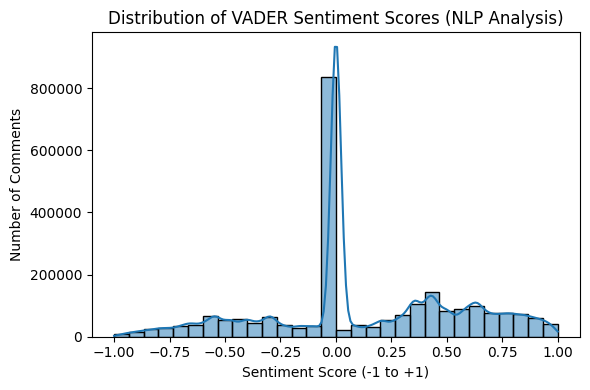

In [52]:
import matplotlib.pyplot as plt
import seaborn as sns

# Ensure correct dataframe is used
# df_top5_sentiment_ready must exist

plt.figure(figsize=(6,4))

sns.histplot(
    df_top5_sentiment_ready["sentiment_score"],
    bins=30,
    kde=True
)

plt.title("Distribution of VADER Sentiment Scores (NLP Analysis)")
plt.xlabel("Sentiment Score (-1 to +1)")
plt.ylabel("Number of Comments")

plt.tight_layout()
plt.show()

## Plot Sentiment Score Distribution

Creates a histogram to visualise the distribution of VADER sentiment scores across Reddit comments in the dataset.

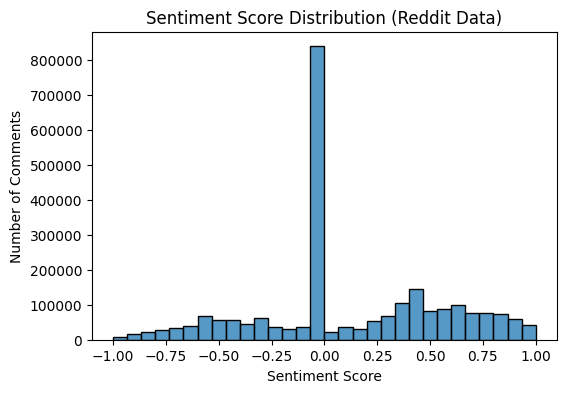

In [27]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6,4))
sns.histplot(df_top5_sentiment_ready["sentiment_score"], bins=30)

plt.title("Sentiment Score Distribution (Reddit Data)")
plt.xlabel("Sentiment Score")
plt.ylabel("Number of Comments")

plt.show()

## Plot Sentiment Score Distribution for Top Communities

Creates a histogram of VADER sentiment scores for the top 5 communities and adds a vertical line at 0 to indicate neutral sentiment.

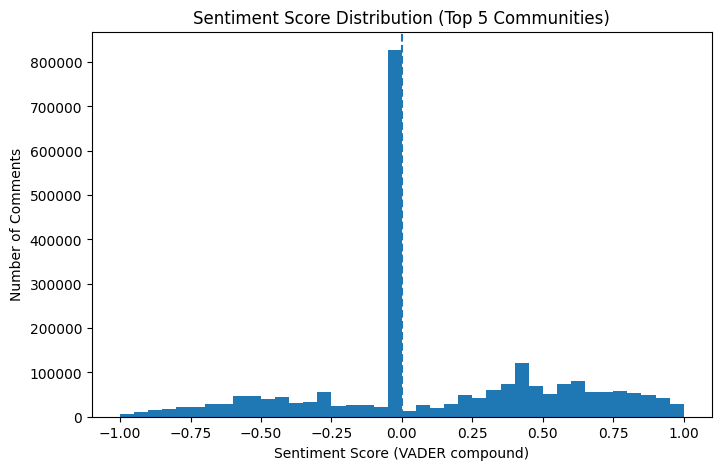

In [29]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.hist(
    df_top5_sentiment_ready["sentiment_score"],
    bins=40
)

plt.title("Sentiment Score Distribution (Top 5 Communities)")
plt.xlabel("Sentiment Score (VADER compound)")
plt.ylabel("Number of Comments")

plt.axvline(0, linestyle="--")  # neutral line

plt.show()

## Compare Average Sentiment Across Communities

Calculates the mean sentiment score for each community and visualises the results using a bar chart to compare overall sentiment across communities.

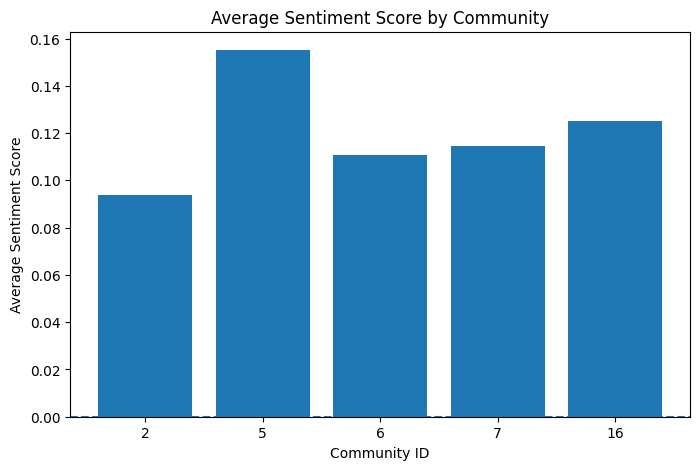

In [30]:
import matplotlib.pyplot as plt

community_sent = df_top5_sentiment_ready.groupby("community_id")["sentiment_score"].mean()

plt.figure(figsize=(8,5))

plt.bar(community_sent.index.astype(str), community_sent.values)

plt.title("Average Sentiment Score by Community")
plt.xlabel("Community ID")
plt.ylabel("Average Sentiment Score")

plt.axhline(0, linestyle="--")

plt.show()

## Sentiment Distribution by Community

Creates a boxplot to compare the distribution of VADER sentiment scores across the top 5 communities, highlighting variation and outliers in sentiment per community.

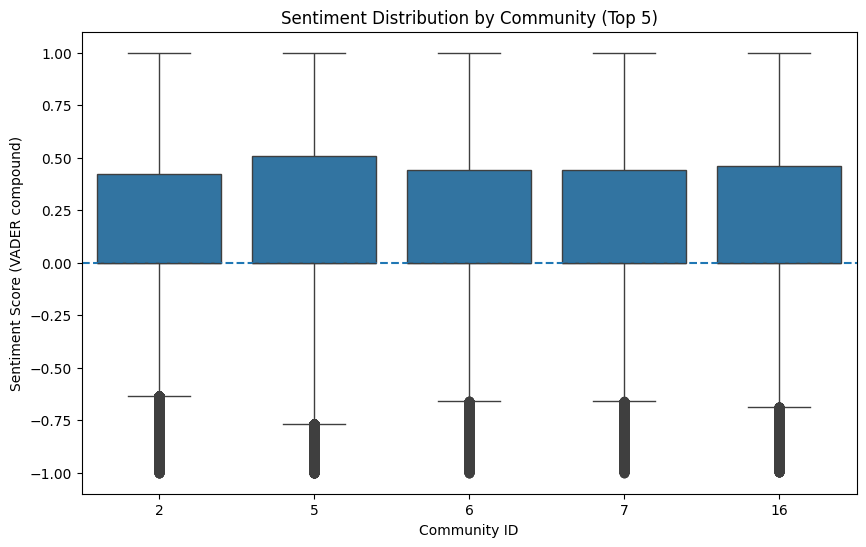

In [31]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10,6))

sns.boxplot(
    data=df_top5_sentiment_ready,
    x="community_id",
    y="sentiment_score"
)

plt.title("Sentiment Distribution by Community (Top 5)")
plt.xlabel("Community ID")
plt.ylabel("Sentiment Score (VADER compound)")

plt.axhline(0, linestyle="--")

plt.show()

## Community Sentiment Heatmap

Aggregates sentiment metrics (average sentiment, low sentiment rate, and total posts) per community and visualises them using a heatmap for easy comparison across the top 5 communities.

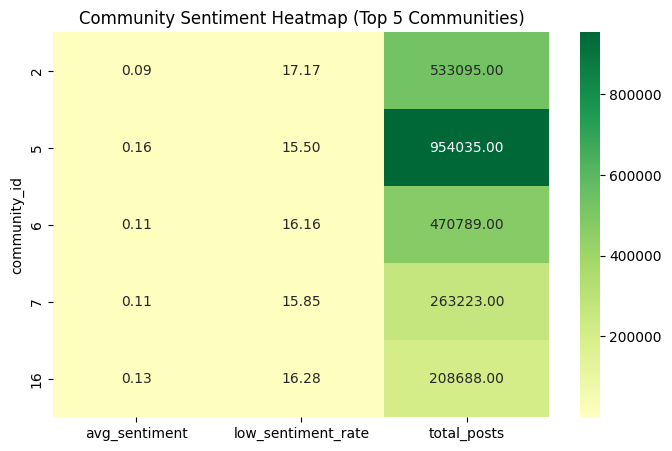

In [32]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Aggregate metrics per community
community_sentiment_summary = df_top5_sentiment_ready.groupby("community_id").agg(
    avg_sentiment=("sentiment_score", "mean"),
    low_sentiment_rate=("is_low_sentiment", "mean"),
    total_posts=("sentiment_score", "count")
).reset_index()

# Convert low sentiment rate to percentage
community_sentiment_summary["low_sentiment_rate"] *= 100

# Set index for heatmap
heatmap_data = community_sentiment_summary.set_index("community_id")

plt.figure(figsize=(8,5))

sns.heatmap(
    heatmap_data,
    annot=True,
    cmap="RdYlGn",
    center=0,
    fmt=".2f"
)

plt.title("Community Sentiment Heatmap (Top 5 Communities)")
plt.show()

## Top Words in Low Sentiment Posts

Extracts and counts the most frequent words from the topic-preprocessed text in low sentiment posts, then visualises the top 15 words using a bar chart.

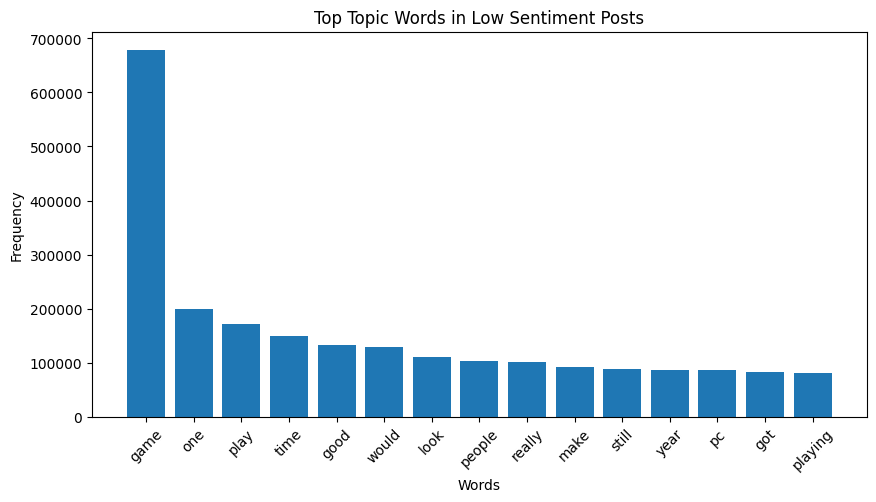

In [36]:
import matplotlib.pyplot as plt
from collections import Counter
import numpy as np

all_words = []

for text in df_top5_sentiment_ready["clean_topic_content"]:
    
    # convert numpy array → list
    if isinstance(text, np.ndarray):
        text = text.tolist()
    
    # flatten safely
    if isinstance(text, list):
        all_words.extend(text)

# count words
word_counts = Counter(all_words)
top_words = word_counts.most_common(15)

words = [w[0] for w in top_words]
counts = [w[1] for w in top_words]

# plot
plt.figure(figsize=(10,5))
plt.bar(words, counts)

plt.title("Top Topic Words in Low Sentiment Posts")
plt.xlabel("Words")
plt.ylabel("Frequency")
plt.xticks(rotation=45)

plt.show()

In [38]:
pip install pyLDAvis

/opt/homebrew/Cellar/python@3.13/3.13.7/Frameworks/Python.framework/Versions/3.13/lib/python3.13/pty.py:95: DeprecationWarning: This process (pid=70237) is multi-threaded, use of forkpty() may lead to deadlocks in the child.
  pid, fd = os.forkpty()



[notice] A new release of pip is available: 25.2 -> 26.1.1
[notice] To update, run: /Users/daniadonai/myenv/bin/python -m pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [43]:
import psutil

print("CPU %:", psutil.cpu_percent())
print("Memory %:", psutil.virtual_memory().percent)

CPU %: 24.5
Memory %: 80.1


In [44]:
print(df_top5_sentiment_ready.shape)
print(df_top5_sentiment_ready.columns)
print(df_top5_sentiment_ready.head(3))

(2429830, 13)
Index(['post_id', 'publish_date', 'user_id', 'parent_id', 'parent_user_id',
       'interaction_type', 'content', 'community_id', 'clean_topic_content',
       'clean_sentiment_content', 'sentiment_score', 'is_low_sentiment',
       'sentiment_label'],
      dtype='str')
                                post_id        publish_date  \
5  37c42d66-39b5-54fa-ab54-44d4d702ce6e 2020-01-01 00:00:19   
8  45aaf625-6089-566c-8c5d-3cf3473453be 2020-01-01 00:00:50   
9  b8265002-6c30-5d6a-ab51-3efac8fae6e9 2020-01-01 00:01:09   

                                user_id                             parent_id  \
5  eb4f0a08-60ba-5b28-827f-0fb524765d4b  1eeba1a7-7e44-5d9d-9e5e-f26221d266ab   
8  41510b4c-f87a-54dc-89e3-a7d1b84ead9d  1eeba1a7-7e44-5d9d-9e5e-f26221d266ab   
9  92c9de18-bf5a-5ff2-a78a-0a29dcf0c48c                                   NaN   

                         parent_user_id interaction_type  \
5  1651d016-161d-535b-ba02-e30609591bc7          COMMENT   
8  1651d016-161d

## Interactive LDA Topic Visualisation (pyLDAvis)

Builds a document-term matrix from the filtered dataset, fits an LDA model, and generates an interactive pyLDAvis visualisation to explore topic structure in the text data.

In [46]:
import pyLDAvis
import pyLDAvis.lda_model
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.decomposition import LatentDirichletAllocation

# USE YOUR FILTERED DATA (NOT FULL DATA)
texts = df_top5_sentiment_ready["clean_topic_content"].astype(str).tolist()

# Vectorizer
vectorizer = CountVectorizer(
    max_df=0.95,
    min_df=2,
    max_features=3000
)

dtm = vectorizer.fit_transform(texts)

# LDA model
lda_model = LatentDirichletAllocation(
    n_components=8,
    random_state=42
)

lda_model.fit(dtm)

# pyLDAvis
pyLDAvis.enable_notebook()

panel = pyLDAvis.lda_model.prepare(
    lda_model,
    dtm,
    vectorizer,
    mds="mmds"
)

panel

/Users/daniadonai/myenv/lib/python3.13/site-packages/sklearn/manifold/_mds.py:744: FutureWarning: The default value of `n_init` will change from 4 to 1 in 1.9. To suppress this warning, provide some value of `n_init`.
  warnings.warn(
/Users/daniadonai/myenv/lib/python3.13/site-packages/sklearn/manifold/_mds.py:754: FutureWarning: The default value of `init` will change from 'random' to 'classical_mds' in 1.10. To suppress this warning, provide some value of `init`.
  warnings.warn(
/Users/daniadonai/myenv/lib/python3.13/site-packages/sklearn/manifold/_mds.py:771: FutureWarning: The `dissimilarity` parameter is deprecated and will be removed in 1.10. Use `metric` instead.
  warnings.warn(


PreparedData(topic_coordinates=              x         y  topics  cluster       Freq
topic                                                
6     -0.093678 -0.081103       1        1  20.745730
3      0.080231 -0.223089       2        1  14.979784
2      0.066201 -0.009389       3        1  14.714229
0     -0.073786  0.203146       4        1  13.937879
4     -0.141185 -0.248369       5        1  12.597255
7      0.173868  0.288682       6        1   8.431432
5      0.329966 -0.054624       7        1   7.439175
1     -0.341617  0.124747       8        1   7.154516, topic_info=        Term           Freq          Total Category  logprob  loglift
1079    game  672919.000000  672919.000000  Default  30.0000  30.0000
1553    look  111607.000000  111607.000000  Default  29.0000  29.0000
1946    play  171962.000000  171962.000000  Default  28.0000  28.0000
1895      pc   87370.000000   87370.000000  Default  27.0000  27.0000
1569    love   59210.000000   59210.000000  Default  26.0000  26.0000
...      ...            ...            ...      ...      ...      ...
1748    need    8866.472370   69164.834171   Topic8  -5.0044   0.5832
1506     let    7167.526474   28878.405469   Topic8  -5.2171   1.2439
2350    shit    7419.309607   48710.239143   Topic8  -5.1826   0.7556
1899  people    6098.709383  103233.350020   Topic8  -5.3786  -0.1915
2307     see    5747.580277   65004.791174   Topic8  -5.4379   0.2117

[618 rows x 6 columns], token_table=      Topic      Freq  Term
term                       
0         1  0.973424   aaa
0         2  0.002423   aaa
0         5  0.023990   aaa
6         1  0.999407    ac
6         3  0.000123    ac
...     ...       ...   ...
2996      3  0.991328  zero
2996      4  0.000120  zero
2996      5  0.001803  zero
2996      6  0.000120  zero
2996      8  0.004327  zero

[2343 rows x 3 columns], R=30, lambda_step=0.01, plot_opts={'xlab': 'PC1', 'ylab': 'PC2'}, topic_order=[7, 4, 3, 1, 5, 8, 6, 2])

## Print LDA Topics

Extracts and displays the top words for each topic from a trained LDA model, using the feature names from the vectorizer.

In [47]:
def print_topics(model, vectorizer, n_words=10):
    words = vectorizer.get_feature_names_out()
    
    for topic_idx, topic in enumerate(model.components_):
        top_words_idx = topic.argsort()[:-n_words - 1:-1]
        top_words = [words[i] for i in top_words_idx]
        
        print(f"\nTopic {topic_idx + 1}:")
        print(", ".join(top_words))

print_topics(lda_model, vectorizer)


Topic 1:
time, year, day, got, back, first, still, one, old, never

Topic 2:
nice, fuck, gaming, mario, gonna, super, removed, true, gamer, fallout

Topic 3:
much, game, world, way, character, would, need, make, time, story

Topic 4:
make, one, buy, people, xbox, console, money, would, use, even

Topic 5:
game, play, pc, one, console, xbox, switch, good, war, want

Topic 6:
look, love, great, life, would, awesome, amazing, red, post, dead

Topic 7:
game, play, people, fun, good, time, video, really, one, player

Topic 8:
man, guy, right, fucking, yes, one, soul, meme, doom, dark


## LDA Topic Word Cloud Visualisation

Generates word clouds for each LDA topic by extracting the most important words and their weights, then visualising them in a grid layout for easier topic interpretation.

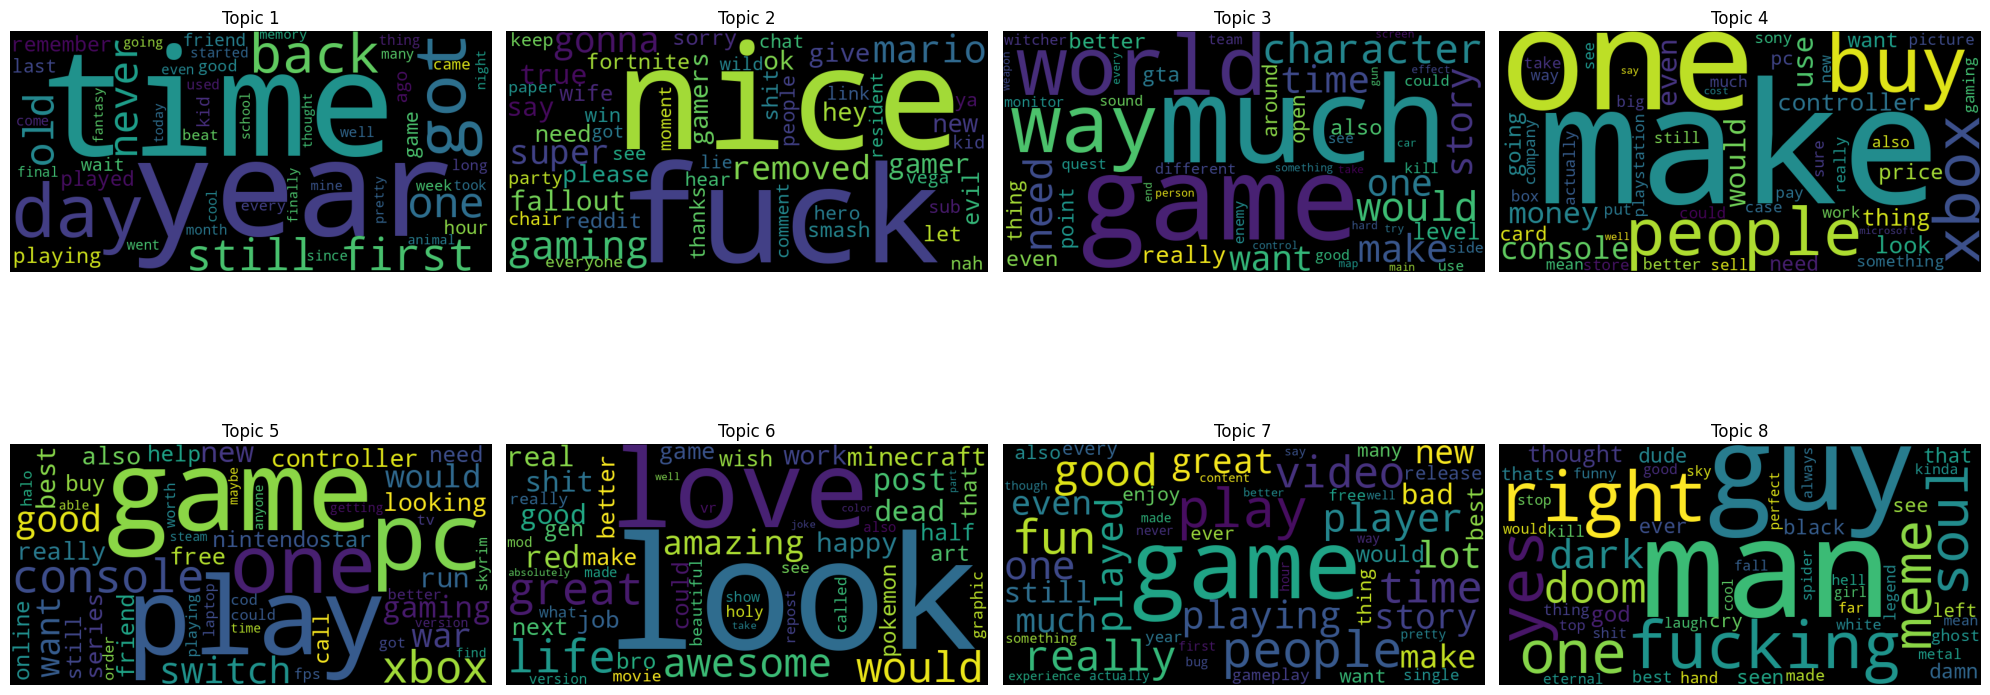

In [48]:
import matplotlib.pyplot as plt
from wordcloud import WordCloud

# Get feature names (words)
words = vectorizer.get_feature_names_out()

# Number of topics
num_topics = lda_model.n_components

# Create subplot grid (2 rows x 4 columns)
fig, axes = plt.subplots(2, 4, figsize=(20, 10))
axes = axes.flatten()

for topic_idx, topic in enumerate(lda_model.components_):
    
    # Get top words for topic
    top_words_idx = topic.argsort()[:-50 - 1:-1]
    
    topic_words = {
        words[i]: topic[i] for i in top_words_idx
    }
    
    # Create word cloud
    wc = WordCloud(
        background_color='black',
        width=800,
        height=400
    ).generate_from_frequencies(topic_words)
    
    # Plot
    axes[topic_idx].imshow(wc)
    axes[topic_idx].set_title(f"Topic {topic_idx + 1}", fontsize=12)
    axes[topic_idx].axis("off")

plt.tight_layout()
plt.show()